# Block Size Benchmark Analysis
---

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
RESULTS_DIR = '../results/size/'
N_NODES      = 1000
K            = 32
BLOCK_SIZES  = [128, 512, 1024, 4096]   # KB
PROTOCOLS    = ['kadcast', 'kadrlnc', 'optimump2p']
COLORS       = {'kadcast': '#E63946', 'kadrlnc': '#2A9D8F', 'optimump2p': '#E9C46A'}
LABELS       = {'kadcast': 'Kadcast', 'kadrlnc': 'KadRLNC', 'optimump2p': 'OPTIMUMP2P'}
MARKERS      = {'kadcast': 'o', 'kadrlnc': 's', 'optimump2p': '^'}

plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'monospace',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})
print('Setup complete.')

Setup complete.


In [2]:
# Load all CSVs
def load_size_data(results_dir, protocols, block_sizes_kb):
    deliveries = {p: {} for p in protocols}
    shards     = {p: {} for p in protocols}
    for p in protocols:
        for size_kb in block_sizes_kb:
            label   = f'{size_kb}kb'
            d_files = sorted(glob.glob(os.path.join(results_dir, f'{p}_*_{label}_deliveries.csv')))
            s_files = sorted(glob.glob(os.path.join(results_dir, f'{p}_*_{label}_shards.csv')))
            d_frames, s_frames = [], []
            for path in d_files:
                seed = int(os.path.basename(path).split('_')[1])
                df   = pd.read_csv(path); df['seed'] = seed; d_frames.append(df)
            for path in s_files:
                seed = int(os.path.basename(path).split('_')[1])
                df   = pd.read_csv(path); df['seed'] = seed; s_frames.append(df)
            deliveries[p][size_kb] = pd.concat(d_frames, ignore_index=True) if d_frames else pd.DataFrame()
            shards[p][size_kb]     = pd.concat(s_frames, ignore_index=True) if s_frames else pd.DataFrame()
        print(f'{p}: loaded {len(block_sizes_kb)} block sizes')
    return deliveries, shards

deliveries, shards = load_size_data(RESULTS_DIR, PROTOCOLS, BLOCK_SIZES)

for p in PROTOCOLS:
    for size_kb in BLOCK_SIZES:
        df = deliveries[p][size_kb]
        if not df.empty:
            df['rel_time'] = df['time_ms'] - df.groupby(['seed','block_id'])['time_ms'].transform('min')
print('Data loaded.')

kadcast: loaded 4 block sizes
kadrlnc: loaded 4 block sizes
optimump2p: loaded 4 block sizes
Data loaded.


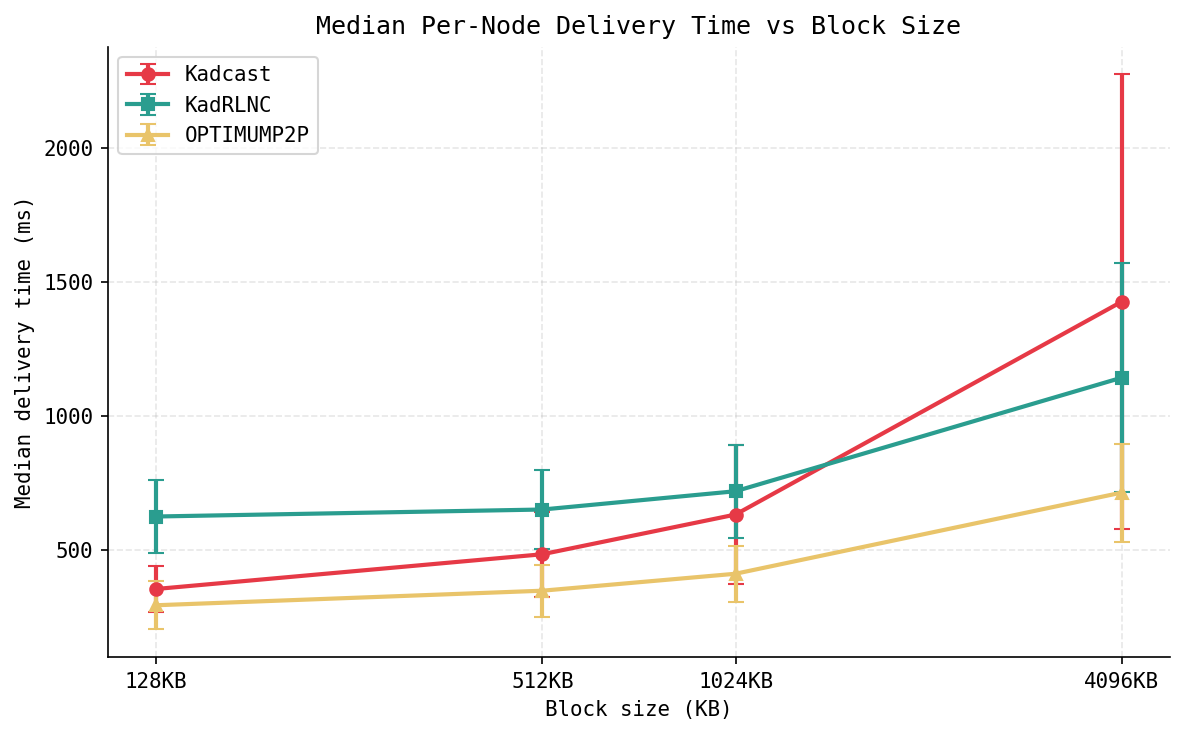

In [3]:
# 1. Median delivery time vs block size
fig, ax = plt.subplots(figsize=(8, 5))
for p in PROTOCOLS:
    medians, stds = [], []
    for size_kb in BLOCK_SIZES:
        times = deliveries[p][size_kb]
        times = times[times['rel_time'] > 0]['rel_time']
        medians.append(times.median()); stds.append(times.std())
    ax.errorbar(BLOCK_SIZES, medians, yerr=stds, color=COLORS[p],
                marker=MARKERS[p], lw=2, capsize=4, label=LABELS[p])
ax.set_xlabel('Block size (KB)')
ax.set_ylabel('Median delivery time (ms)')
ax.set_title('Median Per-Node Delivery Time vs Block Size')
ax.set_xscale('log', base=2)
ax.set_xticks(BLOCK_SIZES); ax.set_xticklabels([f'{s}KB' for s in BLOCK_SIZES])
ax.legend(); plt.tight_layout()
plt.savefig('../figures/size/size_median_delivery.png', bbox_inches='tight'); plt.show()

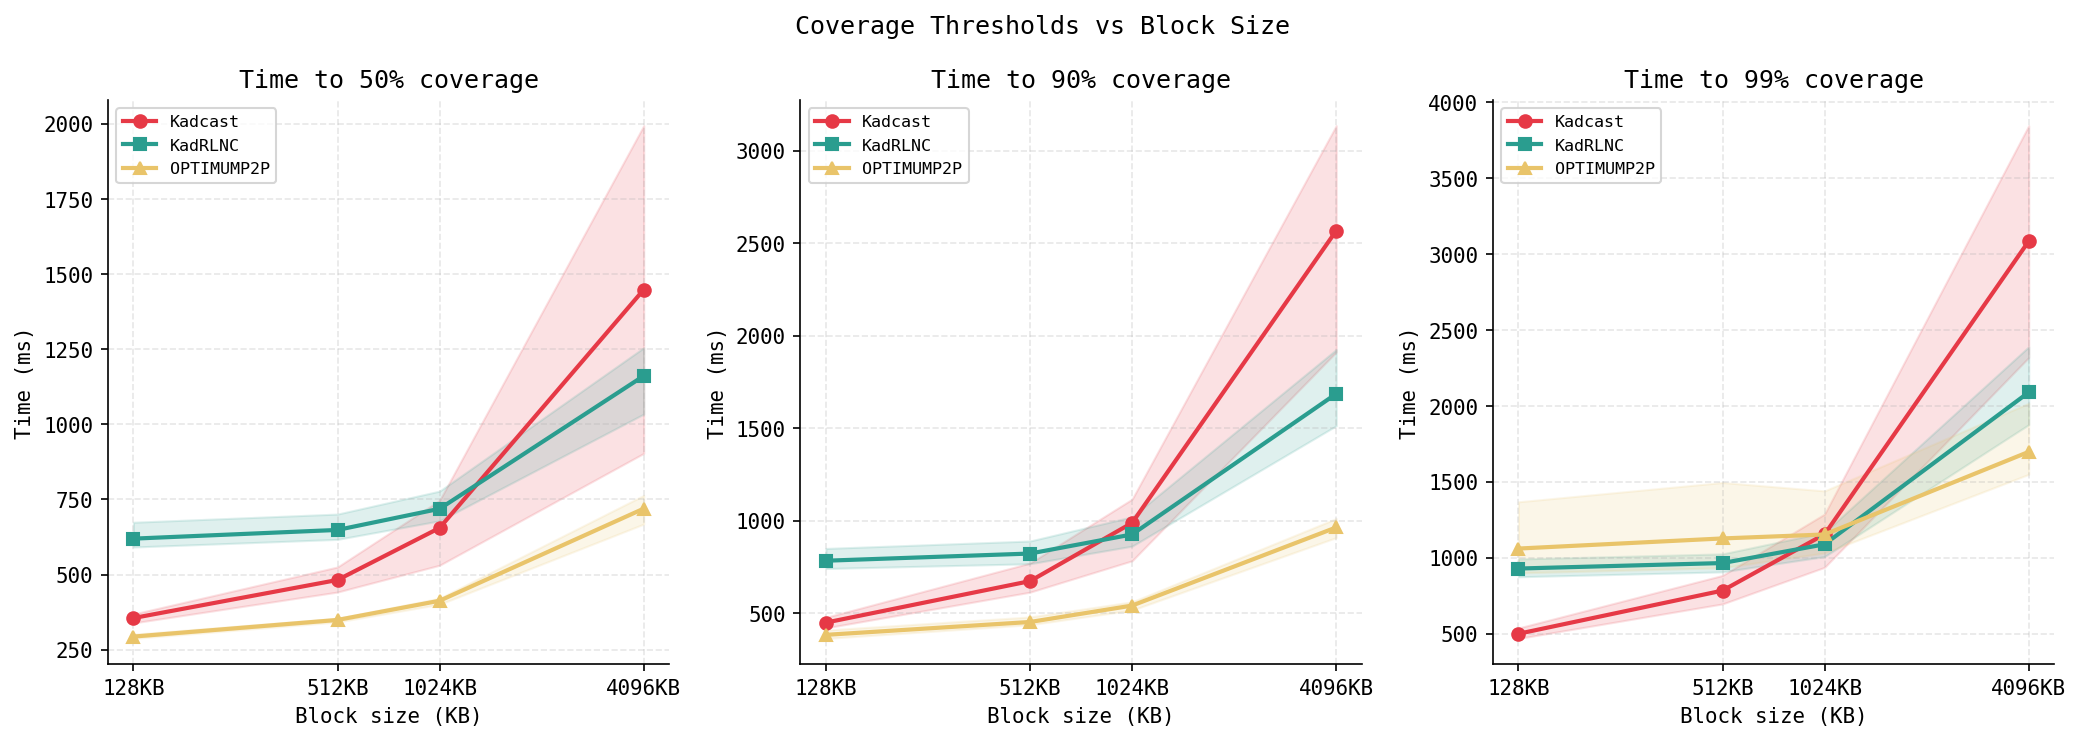

In [4]:
# 2. Time to 50/90/99% coverage vs block size
THRESHOLDS = [0.50, 0.90, 0.99]

def time_to_coverage(df, threshold, n_nodes):
    times = []
    for (seed, block), group in df.groupby(['seed', 'block_id']):
        sorted_t = np.sort(group['rel_time'].values)
        idx = min(int(np.ceil(threshold * n_nodes)) - 1, len(sorted_t) - 1)
        times.append(sorted_t[idx])
    return times

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, thr in zip(axes, THRESHOLDS):
    for p in PROTOCOLS:
        medians, lo, hi = [], [], []
        for size_kb in BLOCK_SIZES:
            t = time_to_coverage(deliveries[p][size_kb], thr, N_NODES)
            medians.append(np.median(t)); lo.append(np.percentile(t,10)); hi.append(np.percentile(t,90))
        ax.plot(BLOCK_SIZES, medians, color=COLORS[p], marker=MARKERS[p], lw=2, label=LABELS[p])
        ax.fill_between(BLOCK_SIZES, lo, hi, color=COLORS[p], alpha=0.15)
    ax.set_xlabel('Block size (KB)'); ax.set_ylabel('Time (ms)')
    ax.set_title(f'Time to {int(thr*100)}% coverage')
    ax.set_xscale('log', base=2)
    ax.set_xticks(BLOCK_SIZES); ax.set_xticklabels([f'{s}KB' for s in BLOCK_SIZES])
    ax.legend(fontsize=8)
plt.suptitle('Coverage Thresholds vs Block Size', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/size/size_coverage_thresholds.png', bbox_inches='tight'); plt.show()

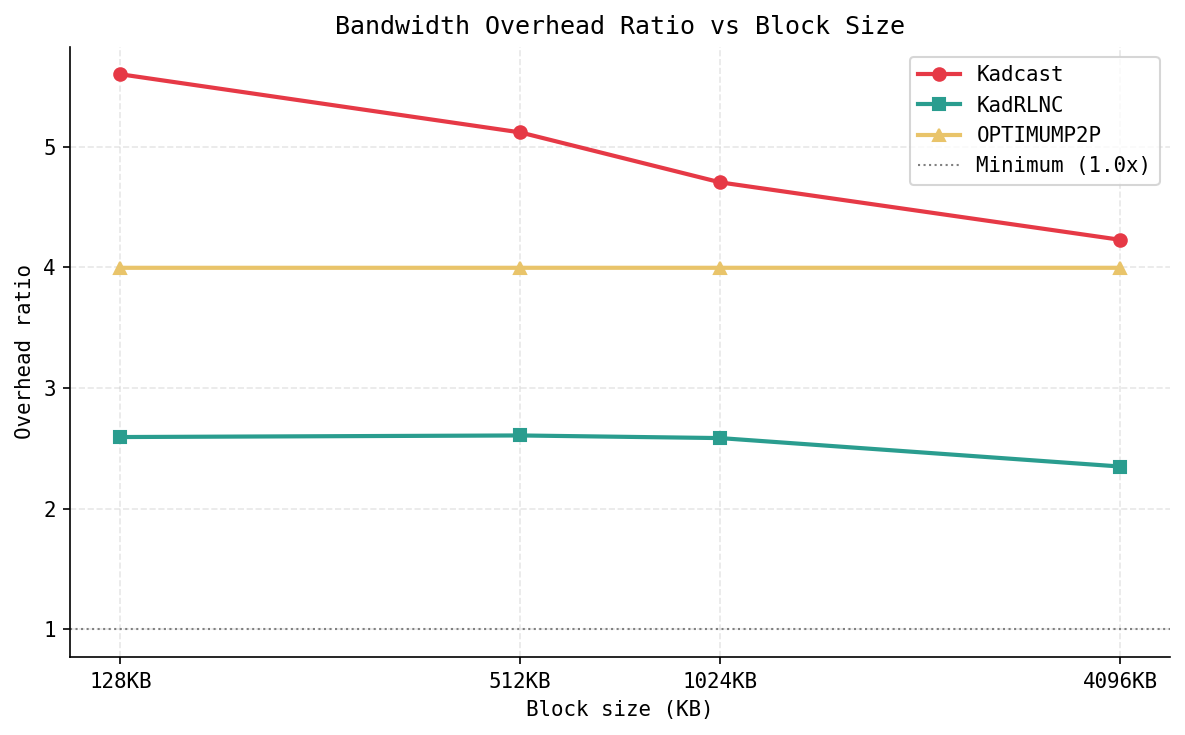

In [5]:
# 3. Bandwidth overhead ratio vs block size
fig, ax = plt.subplots(figsize=(8, 5))
for p in PROTOCOLS:
    ratios = []
    for size_kb in BLOCK_SIZES:
        df_s = shards[p][size_kb]; df_d = deliveries[p][size_kb]
        if df_s.empty or df_d.empty: ratios.append(np.nan); continue
        decoded = df_d.groupby(['seed','block_id'])['node_id'].count().reset_index()
        decoded.columns = ['seed','block_id','decoded_count']
        merged = df_s.merge(decoded, on=['seed','block_id'])
        ratios.append((merged['shard_count'] / (K * merged['decoded_count'])).mean())
    ax.plot(BLOCK_SIZES, ratios, color=COLORS[p], marker=MARKERS[p], lw=2, label=LABELS[p])
ax.axhline(1.0, color='grey', lw=1, ls=':', label='Minimum (1.0x)')
ax.set_xlabel('Block size (KB)'); ax.set_ylabel('Overhead ratio')
ax.set_title('Bandwidth Overhead Ratio vs Block Size')
ax.set_xscale('log', base=2)
ax.set_xticks(BLOCK_SIZES); ax.set_xticklabels([f'{s}KB' for s in BLOCK_SIZES])
ax.legend(); plt.tight_layout()
plt.savefig('../figures/size/size_overhead.png', bbox_inches='tight'); plt.show()

In [6]:
# Summary table
rows = []
for p in PROTOCOLS:
    for size_kb in BLOCK_SIZES:
        df    = deliveries[p][size_kb]
        times = df[df['rel_time'] > 0]['rel_time']
        cov50 = np.median(time_to_coverage(df, 0.50, N_NODES))
        cov99 = np.median(time_to_coverage(df, 0.99, N_NODES))
        df_s  = shards[p][size_kb]
        decoded = df.groupby(['seed','block_id'])['node_id'].count().reset_index()
        decoded.columns = ['seed','block_id','decoded_count']
        merged = df_s.merge(decoded, on=['seed','block_id'])
        overhead = (merged['shard_count'] / (K * merged['decoded_count'])).mean()
        rows.append({'Protocol': LABELS[p], 'Block size': f'{size_kb}KB',
                     'Median (ms)': f'{times.median():.0f}', 'T@50% (ms)': f'{cov50:.0f}',
                     'T@99% (ms)': f'{cov99:.0f}', 'Overhead': f'{overhead:.2f}x'})
pd.DataFrame(rows).set_index(['Protocol','Block size'])

Median (ms) T@50% (ms) T@99% (ms) Overhead
Protocol   Block size                                           
Kadcast    128KB              354        355        500    5.60x
           512KB              484        482        785    5.12x
           1024KB             632        655       1156    4.70x
           4096KB            1427       1449       3086    4.23x
KadRLNC    128KB              624        620        930    2.59x
           512KB              651        649        966    2.61x
           1024KB             719        719       1090    2.58x
           4096KB            1143       1161       2090    2.35x
OPTIMUMP2P 128KB              293        293       1062    4.00x
           512KB              347        349       1128    4.00x
           1024KB             411        413       1154    4.00x
           4096KB             714        719       1698    4.00x